In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import wittgenstein as lw
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB as nb
from sklearn.neural_network import MLPClassifier


##  I. Data Preparation & EDA

### 1. Loading Data

In [38]:
df = pd.read_csv("fish.csv")

In [39]:
print(f'Dataset shape: {df.shape}')

Dataset shape: (7159, 7)


In [40]:
print(df.head())

   Weight  Length1  Length2  Length3   Height   Width Species
0   242.0     23.2     25.4     30.0  11.5200  4.0200   Bream
1   290.0     24.0     26.3     31.2  12.4800  4.3056   Bream
2   340.0     23.9     26.5     31.1  12.3778  4.6961   Bream
3   363.0     26.3     29.0     33.5  12.7300  4.4555   Bream
4   430.0     26.5     29.0     34.0  12.4440  5.1340   Bream


### 2. Data Inspection

In [41]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7159 entries, 0 to 7158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Weight   7159 non-null   float64
 1   Length1  7159 non-null   float64
 2   Length2  7159 non-null   float64
 3   Length3  7159 non-null   float64
 4   Height   7159 non-null   float64
 5   Width    7159 non-null   float64
 6   Species  7159 non-null   str    
dtypes: float64(6), str(1)
memory usage: 430.5 KB
None


### 3. Descriptive Statistics

In [42]:
df.describe()

,Weight,Length1,Length2,Length3,Height,Width
count,7159.000000,7159.000000,7159.000000,7159.000000,7159.000000,7159.000000
mean,442.452424,26.049658,27.972440,44.186604,8.502478,4.762519
std,380.614537,10.978722,11.925595,39.704131,4.056575,1.847965
min,0.000000,7.100000,8.000000,8.000000,1.002400,1.001700
25%,131.000000,18.100000,19.200000,25.050000,6.265850,3.116850
50%,335.000000,25.500000,27.600000,34.400000,8.572800,4.628000
75%,711.000000,32.100000,34.700000,42.900000,10.830000,6.332000
max,1650.000000,59.000000,63.900000,228.800000,19.000000,8.142000


### 4. Handling Missing Values

In [43]:
print(df.isnull().sum())

Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
Species    0
dtype: int64


### 5. Removing Duplicates

In [44]:
print(df.duplicated().sum())

0


In [45]:
print("Input Features:")
print(list(df.columns[:-1]))

print("\nTarget Variable:")
print([df.columns[-1]])

Input Features:
['Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width']

Target Variable:
['Species']


In [46]:
print(df["Species"].unique().tolist())

['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt']


### 6. Distribution of Numerical Features

**Observation:**
- Most features are not normally distributed
- Some features (e.g., Weight, Length3) are right-skewed
- Features have different ranges and scales → scaling is required

In [47]:
numeric_features = [col for col in df.select_dtypes(include=['int64','float64']).columns]

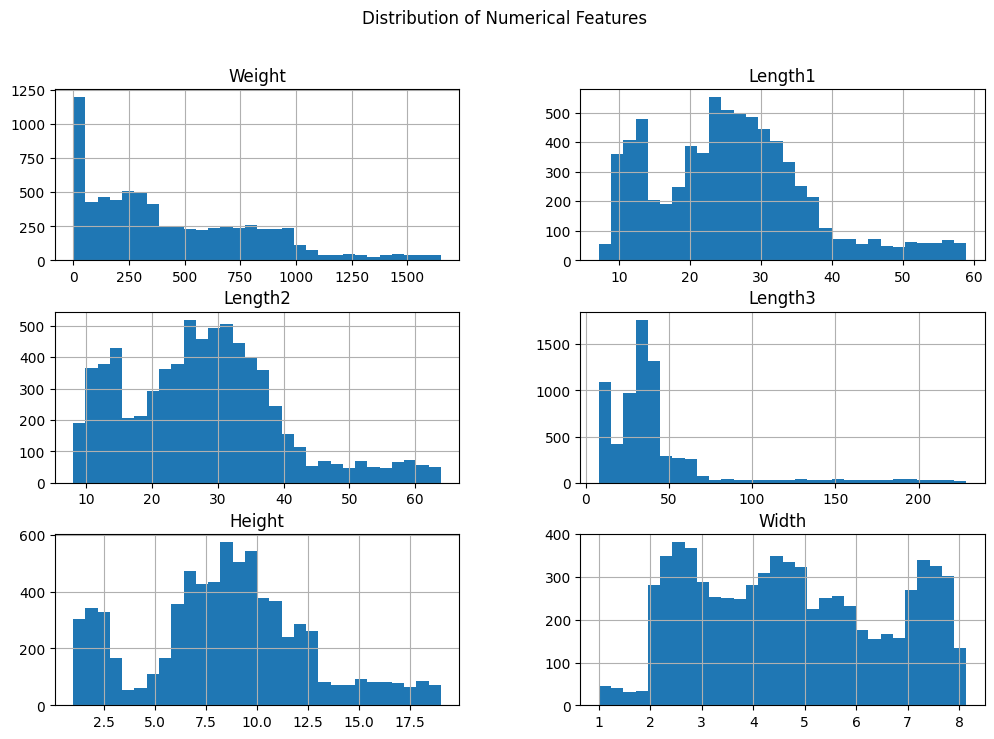

In [48]:
df[numeric_features].hist(bins=30, figsize=(12,8))
plt.suptitle("Distribution of Numerical Features")
plt.show()

### 7. Outliers Detection using Boxplot

**Observation:**
- Several features contain outliers, especially Length3 and Weight
- Extreme values may affect model performance
- Outliers were handled using clipping (Winsorization)

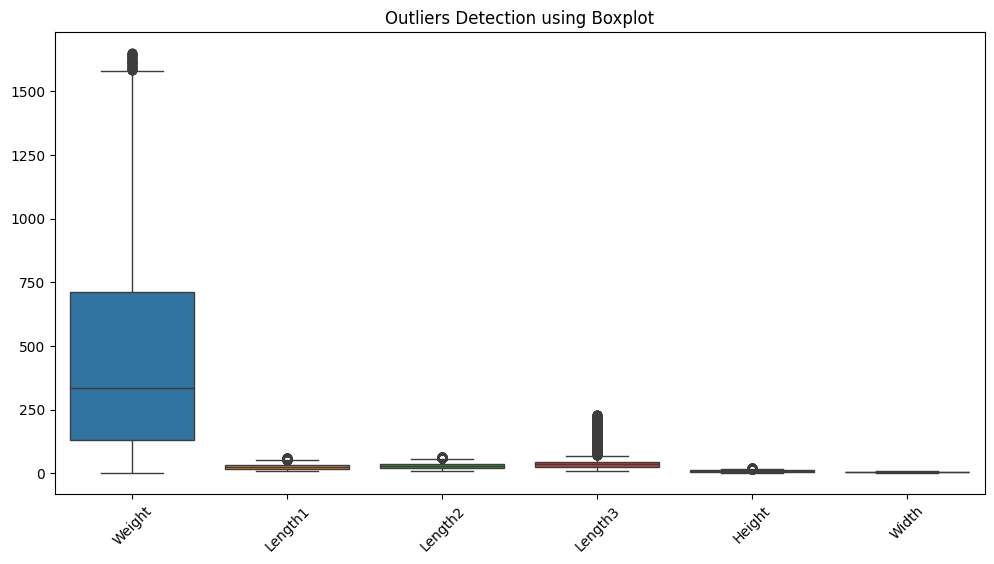

In [49]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_features])
plt.title("Outliers Detection using Boxplot")
plt.xticks(rotation=45)
plt.show()

### 8. Correlation Heatmap

- Weight has strong positive correlation with Length1 (0.64) and Length2 (0.65)
- Length1 and Length2 are highly correlated (0.77) 
- Length3 shows very weak correlation with most features
- Height and Width have moderate correlation with other features

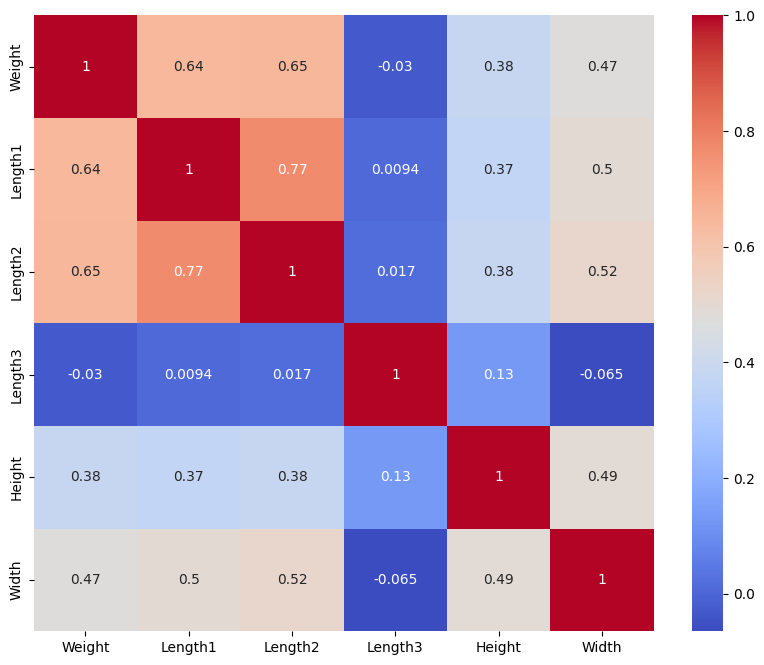

In [50]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_features].corr(), annot=True, cmap='coolwarm')
plt.show()

### 9. Multivariate Relationship Analysis (Pair Plot)

 Comprehensive view of feature relationships and species clustering

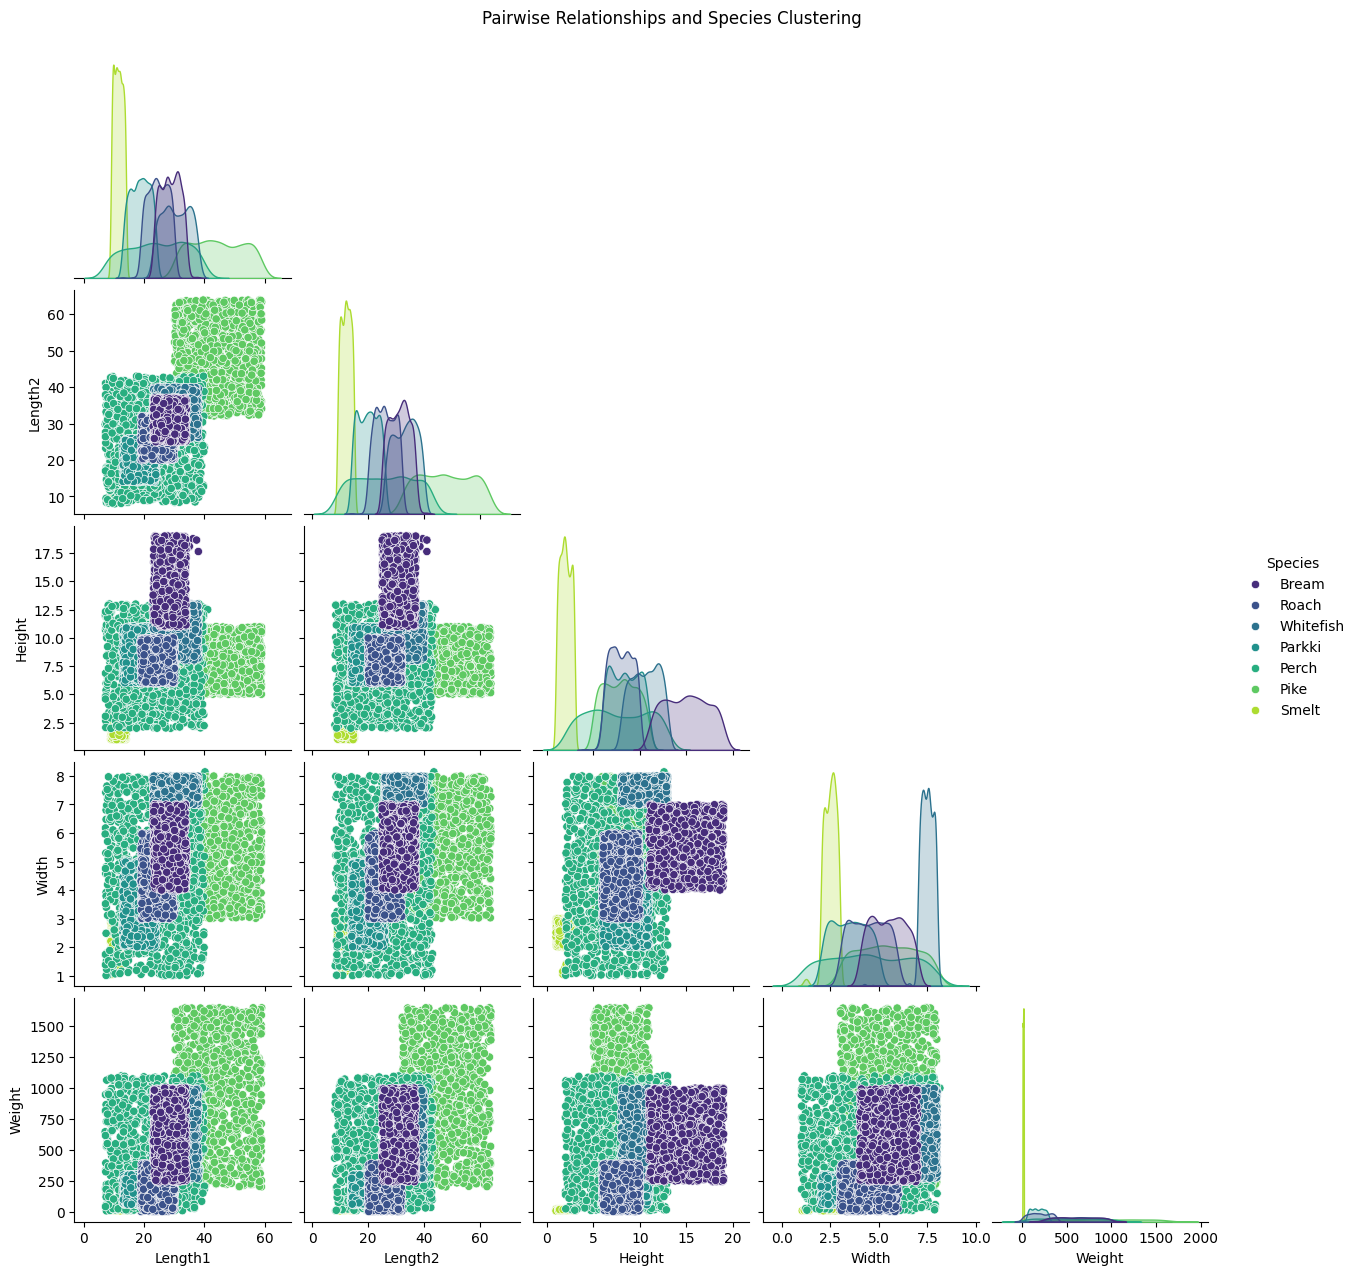

In [51]:
sns.pairplot(df[['Length1', 'Length2', 'Height', 'Width', 'Weight', 'Species']], 
             hue='Species', 
             palette='viridis',
             diag_kind='kde',
             corner=True) # Corner=True removes redundant mirrored plots
plt.suptitle("Pairwise Relationships and Species Clustering", y=1.02)
plt.show()

### 10. Multivariate Feature Profile Analysis (Parallel Coordinates Plot)

Comparing fish species patterns across scaled numerical features

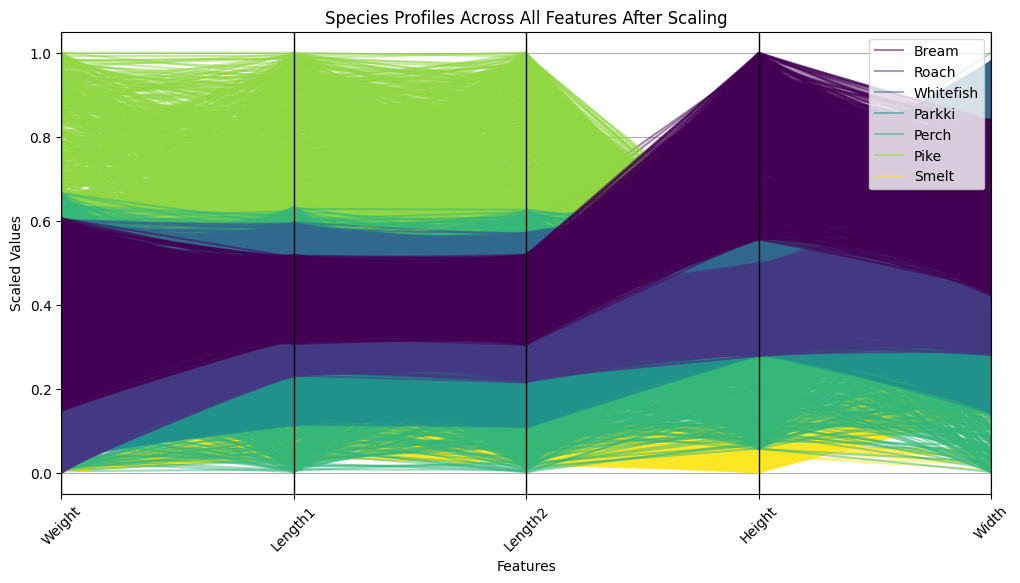

In [52]:
from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

features = ['Weight', 'Length1', 'Length2', 'Height', 'Width']

df_scaled = df.copy()

scaler = MinMaxScaler()
df_scaled[features] = scaler.fit_transform(df_scaled[features])

plt.figure(figsize=(12, 6))

parallel_coordinates(
    df_scaled[features + ['Species']],
    'Species',
    colormap='viridis',
    alpha=0.5
)

plt.title("Species Profiles Across All Features After Scaling")
plt.xlabel("Features")
plt.ylabel("Scaled Values")
plt.xticks(rotation=45)
plt.show()

### 11. Species Count (Class Balance)

- The dataset appears well-balanced across species, as shown in the count plot, which supports reliable classification modeling without significant bias.  

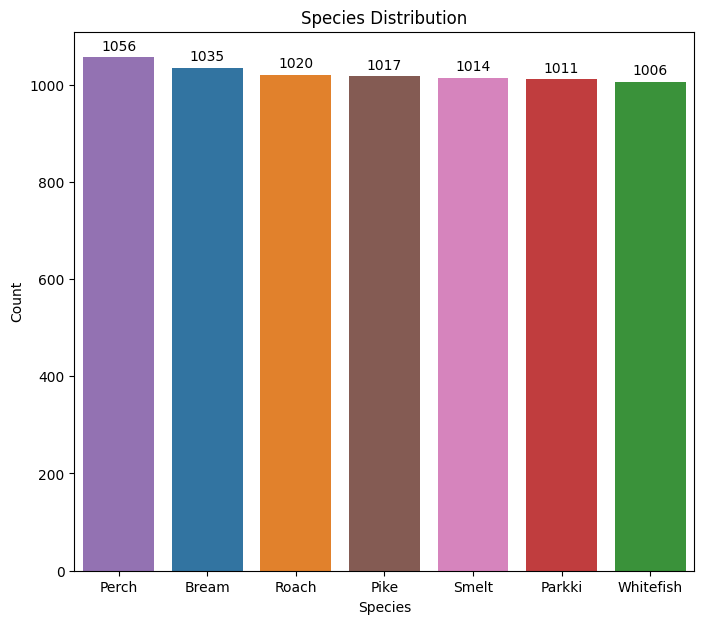

Species
Perch        1056
Bream        1035
Roach        1020
Pike         1017
Smelt        1014
Parkki       1011
Whitefish    1006
Name: count, dtype: int64


In [53]:
order = df["Species"].value_counts().index

plt.figure(figsize=(8,7))

ax = sns.countplot(
    x='Species',
    data=df,
    order=order,
    hue='Species',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Species Distribution")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

print(df["Species"].value_counts())

### 12. Length Distribution per Species

- Violin plots show noticeable differences in length distributions between species, highlighting unique morphological characteristics for each species.  

- Some species (e.g., Parkki) exhibit a wider spread in size, while others (e.g., Smelt) show more compact distributions.  

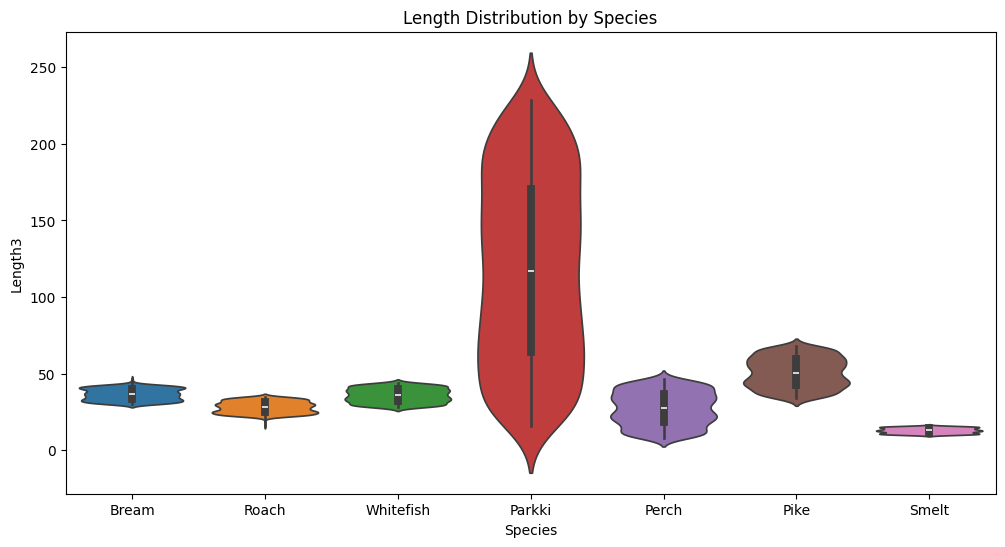

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.violinplot(x='Species', y='Length3', data=df, hue='Species')
plt.title("Length Distribution by Species")
plt.show()

### 13. Weight Distribution by Species

Comparing the weight variation across different fish species

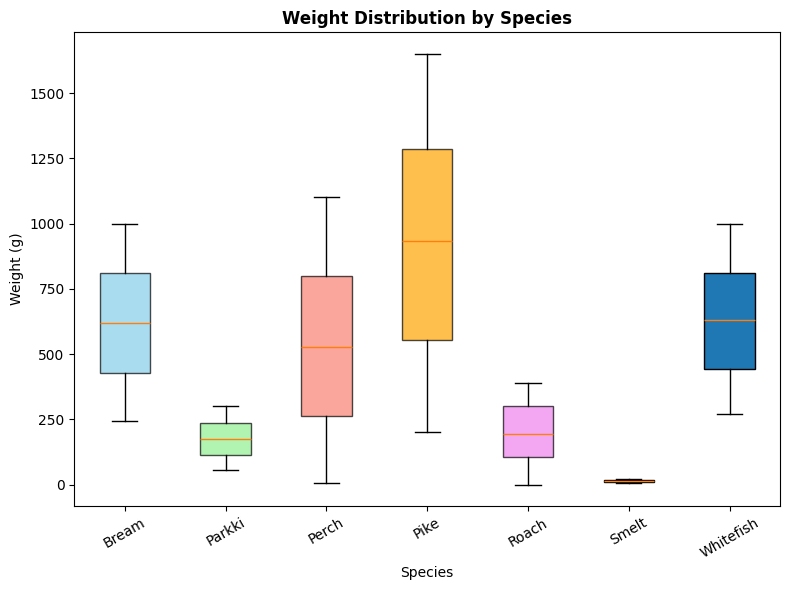

In [55]:
# Box plot - Weight by Species
species_list = sorted(df['Species'].unique())

data_by_species = [
    df[df['Species'] == sp]['Weight'].dropna().values 
    for sp in species_list
]

colors = ['skyblue', 'lightgreen', 'salmon', 'orange', 'violet']

fig, ax = plt.subplots(figsize=(8, 6))

bp = ax.boxplot(
    data_by_species,
    tick_labels=species_list,
    patch_artist=True
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Weight Distribution by Species', fontweight='bold')
ax.set_xlabel('Species')
ax.set_ylabel('Weight (g)')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 14. Encoding (Target)

In [56]:
le = LabelEncoder()
df["Species_encoded"] = le.fit_transform(df["Species"])

### 15. Handling Outliers (Clipping)

In [57]:
def cap_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        df[col] = df[col].clip(lower, upper)
    
    return df
cols = ['Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width']
df = cap_outliers(df, cols)

In [58]:
df.shape

(7159, 8)

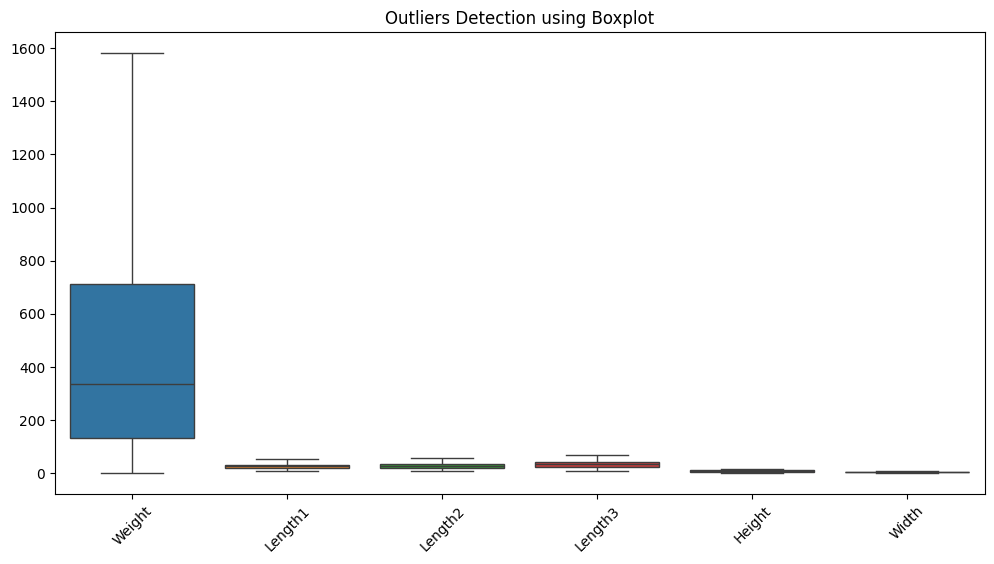

In [59]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_features])
plt.title("Outliers Detection using Boxplot")
plt.xticks(rotation=45)
plt.show()

### 16. Train-Test Split + Shuffle

In [60]:
feature_cols = ['Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width']

X_raw = df[feature_cols].copy()
y = df["Species_encoded"].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y
)

# For RIPPER: keep original Species names
train_df = df.loc[X_train_raw.index].copy()
test_df = df.loc[X_test_raw.index].copy()

y_test_str = test_df["Species"].values
test_features = test_df[feature_cols].copy()

### 17. Standardization (Feature Scaling)

- Standardization was applied instead of normalization
- It is more robust to outliers and suitable for skewed data
- It ensures better performance for distance-based models

In [61]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_raw),
    columns=feature_cols,
    index=X_train_raw.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_raw),
    columns=feature_cols,
    index=X_test_raw.index
)

##  II. Algoritms Implementation

### A. Decision Tree
A Decision Tree recursively partitions the feature space using the best attribute split at each node (based on Gini impurity or Information Gain). The result is an interpretable tree structure where each path from root to leaf encodes a classification rule.

In [62]:
# ── Train Decision Tree ───────────────────────────────────────────────────────
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
dt.fit(X_train_raw, y_train)
y_pred_dt = dt.predict(X_test_raw)

# ── Metrics ───────────────────────────────────────────────────────────────────
acc_dt  = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, average='weighted')
rec_dt  = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt   = f1_score(y_test, y_pred_dt, average='weighted')
cv_dt   = cross_val_score(dt, X_raw, y,
                          cv=StratifiedKFold(5, shuffle=True, random_state=42),
                          scoring='accuracy').mean()

print('=' * 50)
print('       DECISION TREE — RESULTS')
print('=' * 50)
print(f'  Accuracy      : {acc_dt:.4f}  ({acc_dt*100:.2f}%)')
print(f'  Precision     : {prec_dt:.4f}')
print(f'  Recall        : {rec_dt:.4f}')
print(f'  F1-Score      : {f1_dt:.4f}')
print(f'  CV Accuracy   : {cv_dt:.4f}  (5-fold)')
print(f'  Tree Depth    : {dt.get_depth()}')
print(f'  Leaf Nodes    : {dt.get_n_leaves()}')
print('=' * 50)

       DECISION TREE — RESULTS
  Accuracy      : 0.9700  (97.00%)
  Precision     : 0.9700
  Recall        : 0.9700
  F1-Score      : 0.9696
  CV Accuracy   : 0.9663  (5-fold)
  Tree Depth    : 10
  Leaf Nodes    : 57


In [63]:
# ── Per-class Report ──────────────────────────────────────────────────────────
print('=== Classification Report — Decision Tree ===')
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

=== Classification Report — Decision Tree ===
              precision    recall  f1-score   support

       Bream       1.00      0.99      0.99       207
      Parkki       0.96      0.98      0.97       202
       Perch       0.95      0.87      0.91       211
        Pike       0.97      0.98      0.97       204
       Roach       0.94      0.99      0.96       204
       Smelt       1.00      1.00      1.00       203
   Whitefish       0.99      1.00      0.99       201

    accuracy                           0.97      1432
   macro avg       0.97      0.97      0.97      1432
weighted avg       0.97      0.97      0.97      1432



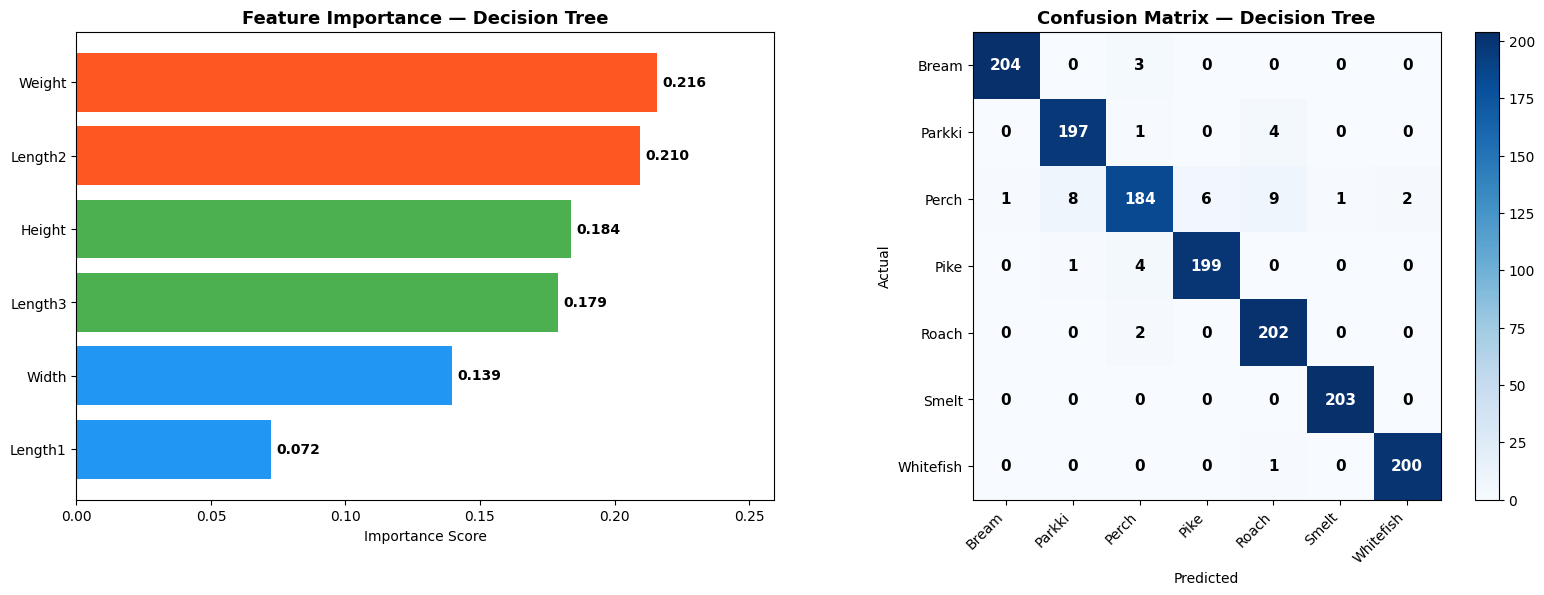

In [64]:
# ── Feature Importance ────────────────────────────────────────────────────────
fi = pd.Series(dt.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fi_colors = ['#2196F3' if v < 0.15 else '#FF5722' if v > 0.20 else '#4CAF50' for v in fi.values]
axes[0].barh(fi.index, fi.values, color=fi_colors)
axes[0].set_title('Feature Importance — Decision Tree', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Importance Score')
for i, v in enumerate(fi.values):
    axes[0].text(v + 0.002, i, f'{v:.3f}', va='center', fontweight='bold')
axes[0].set_xlim(0, max(fi.values) * 1.2)

# Confusion matrix DT
cm_dt = confusion_matrix(y_test, y_pred_dt)
im = axes[1].imshow(cm_dt, cmap='Blues')
axes[1].set_xticks(range(len(le.classes_)))
axes[1].set_yticks(range(len(le.classes_)))
axes[1].set_xticklabels(le.classes_, rotation=45, ha='right')
axes[1].set_yticklabels(le.classes_)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix — Decision Tree', fontweight='bold', fontsize=13)
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        color = 'white' if cm_dt[i,j] > cm_dt.max()/2 else 'black'
        axes[1].text(j, i, cm_dt[i,j], ha='center', va='center',
                    fontweight='bold', color=color, fontsize=11)
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

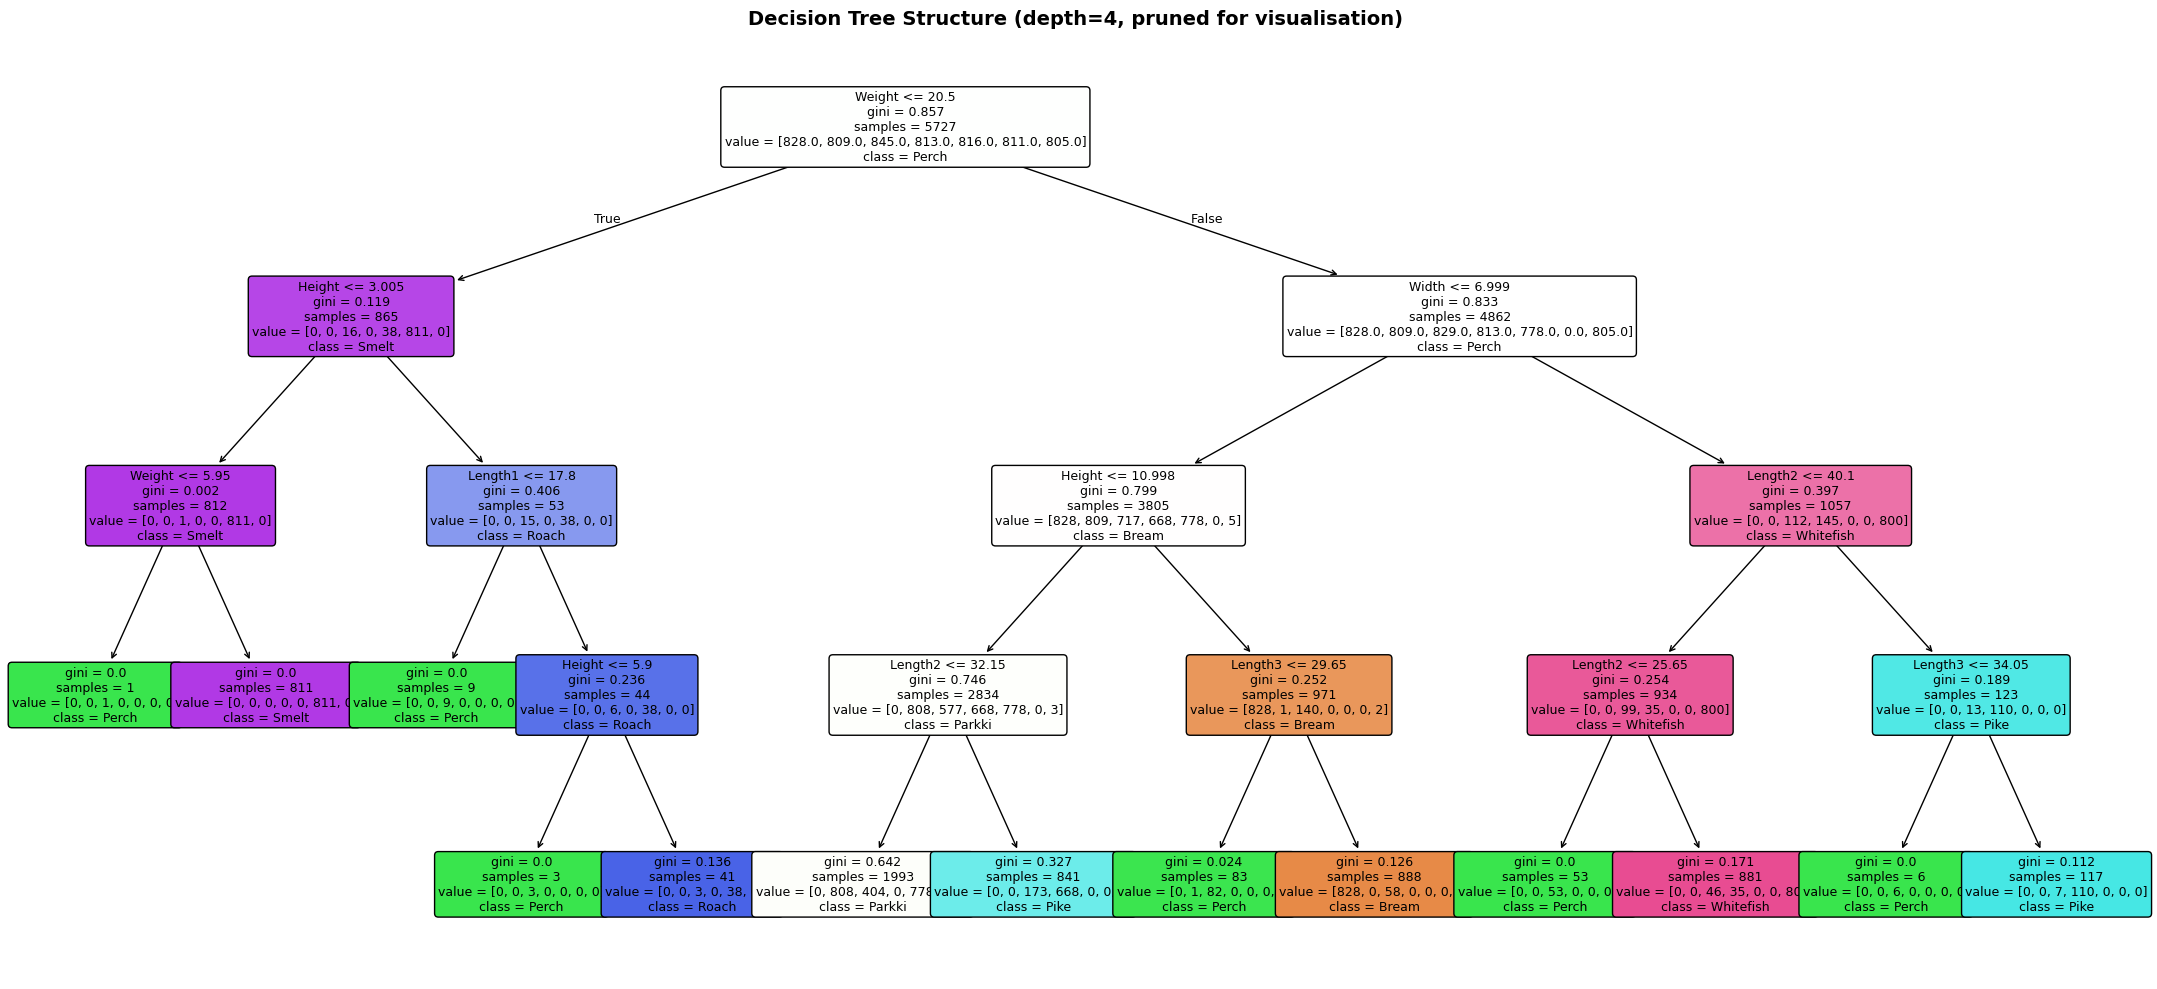

In [65]:
# ── Visualize Pruned Tree (depth=4 for readability) ───────────────────────────
dt_vis = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_vis.fit(X_train_raw, y_train)

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt_vis, feature_names=feature_cols, class_names=le.classes_,
    filled=True, rounded=True, fontsize=9, ax=ax,
    impurity=True, proportion=False
)
ax.set_title('Decision Tree Structure (depth=4, pruned for visualisation)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### B. Rule Induction (RIPPER)

**RIPPER** (Repeated Incremental Pruning to Produce Error Reduction) is a propositional rule learning algorithm. It generates an ordered set of IF-THEN rules by:
1. Growing rules greedily using an information gain criterion
2. Pruning each rule to reduce generalisation error
3. Optimising the final ruleset globally

We use **One-vs-Rest (OvR)** to extend it to 7-class classification.

In [66]:
# ── Train RIPPER (One-vs-Rest) ─────────────────────────────────────────────────

feature_cols = ['Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width']

test_features = test_df[feature_cols].copy()

score_matrix = np.zeros((len(test_df), len(species_list)))
ripper_models = {}

for idx, sp in enumerate(species_list):
    
    train_bin = train_df[feature_cols].copy()
    
    # binary target for one-vs-rest
    train_bin['label'] = (train_df['Species'] == sp).astype(str)

    clf = lw.RIPPER(random_state=42)
    clf.fit(train_bin, class_feat='label', pos_class='True')
    
    ripper_models[sp] = clf

    proba = clf.predict_proba(test_features)
    score_matrix[:, idx] = proba[:, 1]

    print(f'  [{sp}]: {len(clf.ruleset_)} rules learned')

pred_indices = np.argmax(score_matrix, axis=1)
y_pred_ri = np.array([species_list[i] for i in pred_indices])

# ── Metrics ───────────────────────────────────────────────────────────────────
acc_ri  = accuracy_score(y_test_str, y_pred_ri)
prec_ri = precision_score(y_test_str, y_pred_ri, average='weighted', zero_division=0)
rec_ri  = recall_score(y_test_str, y_pred_ri, average='weighted', zero_division=0)
f1_ri   = f1_score(y_test_str, y_pred_ri, average='weighted', zero_division=0)

print()
print('=' * 50)
print('    RULE INDUCTION (RIPPER) — RESULTS')
print('=' * 50)
print(f'  Accuracy  : {acc_ri:.4f}  ({acc_ri*100:.2f}%)')
print(f'  Precision : {prec_ri:.4f}')
print(f'  Recall    : {rec_ri:.4f}')
print(f'  F1-Score  : {f1_ri:.4f}')
total_rules = sum(len(m.ruleset_) for m in ripper_models.values())
print(f'  Total Rules: {total_rules}')
print('=' * 50)

  [Bream]: 26 rules learned
  [Parkki]: 30 rules learned
  [Perch]: 91 rules learned
  [Pike]: 22 rules learned
  [Roach]: 78 rules learned
  [Smelt]: 6 rules learned
  [Whitefish]: 52 rules learned

    RULE INDUCTION (RIPPER) — RESULTS
  Accuracy  : 0.9134  (91.34%)
  Precision : 0.9193
  Recall    : 0.9134
  F1-Score  : 0.9154
  Total Rules: 305


In [67]:
# ── Per-class Report ──────────────────────────────────────────────────────────
print('=== Classification Report — Rule Induction (RIPPER) ===')
print(classification_report(y_test_str, y_pred_ri, zero_division=0))

=== Classification Report — Rule Induction (RIPPER) ===
              precision    recall  f1-score   support

       Bream       0.99      0.96      0.97       207
      Parkki       0.96      0.91      0.93       202
       Perch       0.71      0.82      0.76       211
        Pike       0.99      0.95      0.97       204
       Roach       0.89      0.84      0.86       204
       Smelt       0.98      1.00      0.99       203
   Whitefish       0.93      0.92      0.92       201

    accuracy                           0.91      1432
   macro avg       0.92      0.91      0.92      1432
weighted avg       0.92      0.91      0.92      1432



In [68]:
# ── Sample Induced Rules (most readable classes) ──────────────────────────────
print('=' * 65)
print('         INDUCED RULES — SELECTED SPECIES')
print('=' * 65)

highlight = ['Smelt', 'Pike', 'Bream']
for sp in highlight:
    rules = ripper_models[sp].ruleset_
    print(f'\n▶  {sp.upper()}  ({len(rules)} rules)')
    print('-' * 55)
    for r in rules:
        print(f'   IF {r}')
        print(f'   THEN class = {sp}')
        print()

         INDUCED RULES — SELECTED SPECIES

▶  SMELT  (6 rules)
-------------------------------------------------------
   IF [Weight=<16.0^Height=<2.32]
   THEN class = Smelt

   IF [Length1=<11.86^Weight=<16.0]
   THEN class = Smelt

   IF [Weight=16.0-83.0^Height=<2.32]
   THEN class = Smelt

   IF [Height=2.32-5.39^Length1=11.86-15.1^Weight=<16.0]
   THEN class = Smelt

   IF [Height=2.32-5.39^Weight=16.0-83.0^Length2=<12.5]
   THEN class = Smelt

   IF [Length2=12.5-16.02^Weight=16.0-83.0^Height=2.32-5.39]
   THEN class = Smelt


▶  PIKE  (22 rules)
-------------------------------------------------------
   IF [Length1=>39.3^Length3=>47.88]
   THEN class = Pike

   IF [Length2=>42.1^Length3=>47.88]
   THEN class = Pike

   IF [Length2=>42.1^Length3=37.7-41.3]
   THEN class = Pike

   IF [Length1=>39.3^Length2=>42.1]
   THEN class = Pike

   IF [Length1=>39.3^Length2=36.3-42.1]
   THEN class = Pike

   IF [Length2=>42.1^Length3=41.3-47.88]
   THEN class = Pike

   IF [Weight=>956.0^

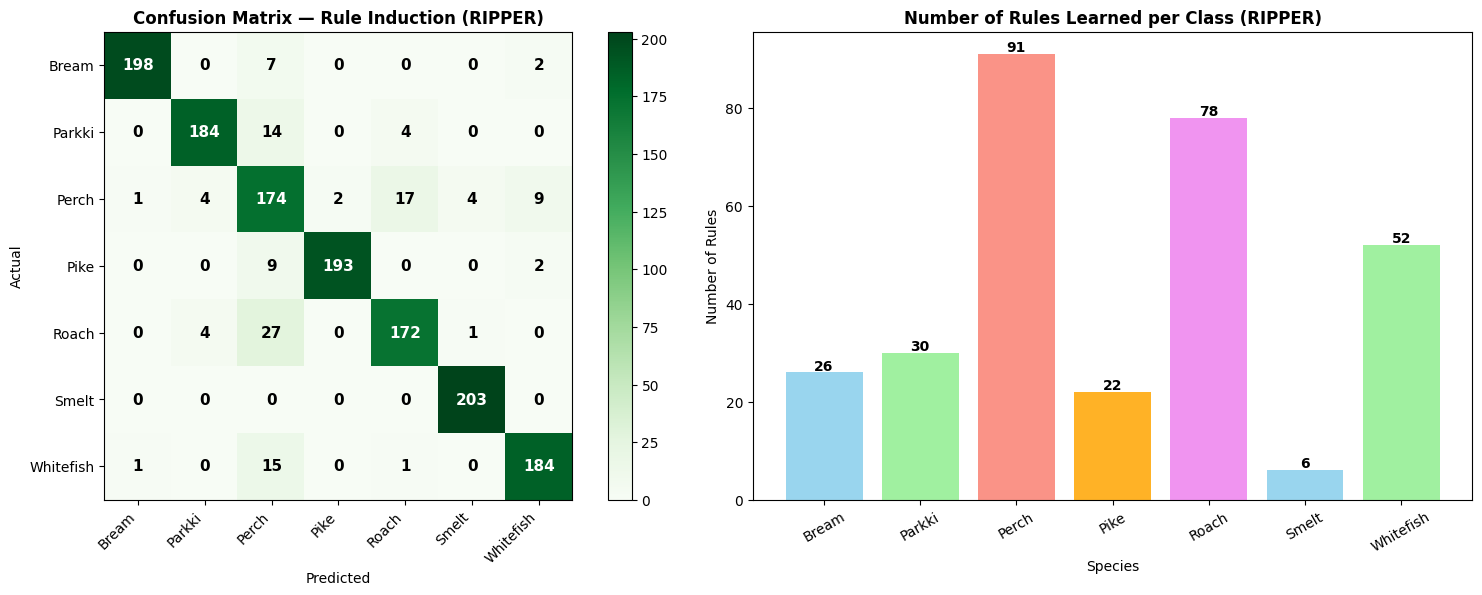

In [69]:
# ── Confusion Matrix — RIPPER ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CM
cm_ri = confusion_matrix(y_test_str, y_pred_ri, labels=species_list)
im = axes[0].imshow(cm_ri, cmap='Greens')
axes[0].set_xticks(range(len(species_list)))
axes[0].set_yticks(range(len(species_list)))
axes[0].set_xticklabels(species_list, rotation=45, ha='right')
axes[0].set_yticklabels(species_list)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix — Rule Induction (RIPPER)', fontweight='bold', fontsize=12)
for i in range(len(species_list)):
    for j in range(len(species_list)):
        color = 'white' if cm_ri[i,j] > cm_ri.max()/2 else 'black'
        axes[0].text(j, i, cm_ri[i,j], ha='center', va='center',
                    fontweight='bold', color=color, fontsize=11)
plt.colorbar(im, ax=axes[0])

# Rule count by class
rule_counts = {sp: len(ripper_models[sp].ruleset_) for sp in species_list}
axes[1].bar(rule_counts.keys(), rule_counts.values(), color=colors, alpha=0.85)
axes[1].set_title('Number of Rules Learned per Class (RIPPER)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Species')
axes[1].set_ylabel('Number of Rules')
axes[1].tick_params(axis='x', rotation=30)
for i, (sp, cnt) in enumerate(rule_counts.items()):
    axes[1].text(i, cnt + 0.5, str(cnt), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('ripper_results.png', dpi=120, bbox_inches='tight')
plt.show()

### C. Naïve Bayes
* Naïve Bayes assumes conditional independence between features given the class label.   
* `GaussianNB` is used here since all features are continuous (Weight, Length, Height, Width).  

In [72]:
nb.fit(X_train_raw, y_train)      
y_pred_nb = nb.predict(X_test_raw)

acc_nb  = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, average='weighted')
rec_nb  = recall_score(y_test, y_pred_nb, average='weighted')
f1_nb   = f1_score(y_test, y_pred_nb, average='weighted')
cv_nb   = cross_val_score(nb, X_raw, y,
                          cv=StratifiedKFold(5, shuffle=True, random_state=42),
                          scoring='accuracy').mean()
print('=' * 50)
print('       NAIVE BAYES — RESULTS')
print('=' * 50)
print(f'  Accuracy      : {acc_nb:.4f}  ({acc_nb*100:.2f}%)')
print(f'  Precision     : {prec_nb:.4f}')
print(f'  Recall        : {rec_nb:.4f}')
print(f'  F1-Score      : {f1_nb:.4f}')
print(f'  CV Accuracy   : {cv_nb:.4f}  (5-fold)')
print('=' * 50)


       NAIVE BAYES — RESULTS
  Accuracy      : 0.9616  (96.16%)
  Precision     : 0.9633
  Recall        : 0.9616
  F1-Score      : 0.9611
  CV Accuracy   : 0.9645  (5-fold)


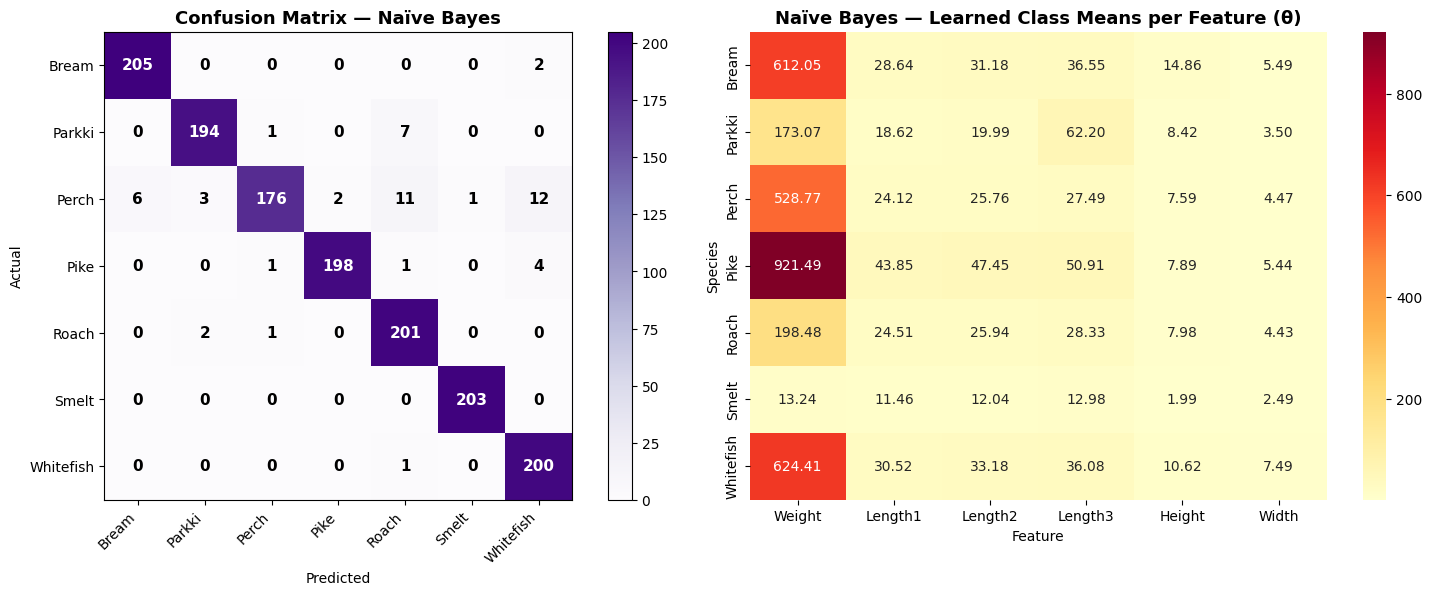

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_nb = confusion_matrix(y_test, y_pred_nb)
im = axes[0].imshow(cm_nb, cmap='Purples')
axes[0].set_xticks(range(len(le.classes_)))
axes[0].set_yticks(range(len(le.classes_)))
axes[0].set_xticklabels(le.classes_, rotation=45, ha='right')
axes[0].set_yticklabels(le.classes_)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix — Naïve Bayes', fontweight='bold', fontsize=13)
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        color = 'white' if cm_nb[i,j] > cm_nb.max()/2 else 'black'
        axes[0].text(j, i, cm_nb[i,j], ha='center', va='center',
                    fontweight='bold', color=color, fontsize=11)
plt.colorbar(im, ax=axes[0])

mean_df = pd.DataFrame(nb.theta_, columns=feature_cols, index=le.classes_)
sns.heatmap(mean_df, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Naïve Bayes — Learned Class Means per Feature (θ)',
                  fontweight='bold', fontsize=13)
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Species')
plt.tight_layout()
plt.show()


### D. Neural Network


Uses `MLPClassifier` with two hidden layers (128 → 64 neurons), ReLU activation, Adam optimizer
early_stopping=True prevents overfitting on this small dataset
Plots the training loss curve so you can see convergence

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20
)
mlp.fit(X_train_scaled, y_train)      # scaled features are used to make training more effective for MLP
y_pred_mlp = mlp.predict(X_test_scaled)

acc_mlp  = accuracy_score(y_test, y_pred_mlp)
prec_mlp = precision_score(y_test, y_pred_mlp, average='weighted')
rec_mlp  = recall_score(y_test, y_pred_mlp, average='weighted')
f1_mlp   = f1_score(y_test, y_pred_mlp, average='weighted')
cv_mlp   = cross_val_score(mlp, X_train_scaled, y_train,
                           cv=StratifiedKFold(5, shuffle=True, random_state=42),
                           scoring='accuracy').mean()

print('=' * 50)
print('      NEURAL NETWORK (MLP) — RESULTS')
print('=' * 50)
print(f'  Accuracy   : {acc_mlp:.4f}  ({acc_mlp*100:.2f}%)')
print(f'  Precision  : {prec_mlp:.4f}')
print(f'  Recall     : {rec_mlp:.4f}')
print(f'  F1-Score   : {f1_mlp:.4f}')
print(f'  CV Accuracy: {cv_mlp:.4f}  (5-fold)')
print(f'  Iterations : {mlp.n_iter_}')
print('=' * 50)


      NEURAL NETWORK (MLP) — RESULTS
  Accuracy   : 0.9609  (96.09%)
  Precision  : 0.9611
  Recall     : 0.9609
  F1-Score   : 0.9605
  CV Accuracy: 0.9628  (5-fold)
  Iterations : 62



=== Classification Report — Neural Network (MLP) ===
              precision    recall  f1-score   support

       Bream       0.97      0.99      0.98       207
      Parkki       0.95      0.98      0.96       202
       Perch       0.96      0.86      0.91       211
        Pike       0.98      0.97      0.98       204
       Roach       0.94      0.96      0.95       204
       Smelt       0.99      1.00      0.99       203
   Whitefish       0.94      0.98      0.96       201

    accuracy                           0.96      1432
   macro avg       0.96      0.96      0.96      1432
weighted avg       0.96      0.96      0.96      1432



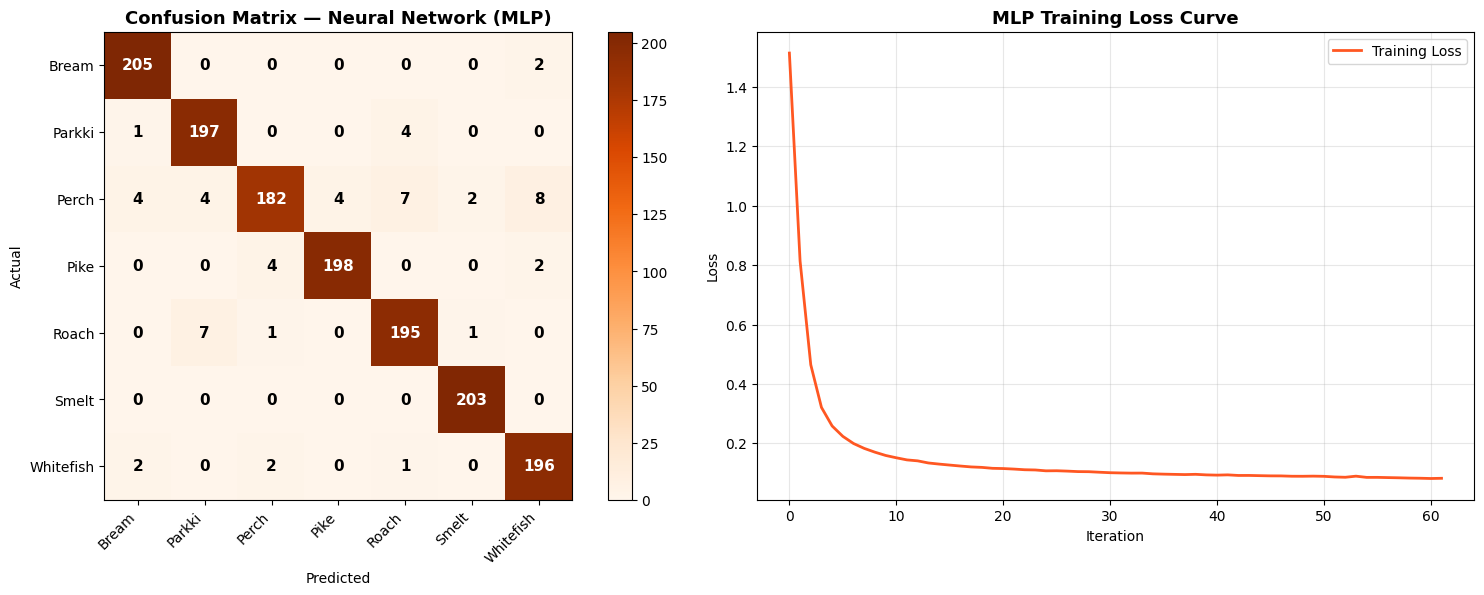

In [76]:
print('\n=== Classification Report — Neural Network (MLP) ===')
print(classification_report(y_test, y_pred_mlp, target_names=le.classes_))

# Confusion Matrix + Loss Curve
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_mlp = confusion_matrix(y_test, y_pred_mlp)
im = axes[0].imshow(cm_mlp, cmap='Oranges')
axes[0].set_xticks(range(len(le.classes_)))
axes[0].set_yticks(range(len(le.classes_)))
axes[0].set_xticklabels(le.classes_, rotation=45, ha='right')
axes[0].set_yticklabels(le.classes_)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix — Neural Network (MLP)', fontweight='bold', fontsize=13)
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        color = 'white' if cm_mlp[i,j] > cm_mlp.max()/2 else 'black'
        axes[0].text(j, i, cm_mlp[i,j], ha='center', va='center',
                    fontweight='bold', color=color, fontsize=11)
plt.colorbar(im, ax=axes[0])

axes[1].plot(mlp.loss_curve_, color='#FF5722', linewidth=2, label='Training Loss')
axes[1].set_title('MLP Training Loss Curve', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## III. Comparison of Classification Results

### Decision Tree vs Rule Induction

In [ ]:
# ── Summary Table ──────────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1-Score (weighted)', 'CV Accuracy (5-fold)'],
    'Decision Tree': [f'{acc_dt:.4f}', f'{prec_dt:.4f}', f'{rec_dt:.4f}', f'{f1_dt:.4f}', f'{cv_dt:.4f}'],
    'Rule Induction': [f'{acc_ri:.4f}', f'{prec_ri:.4f}', f'{rec_ri:.4f}', f'{f1_ri:.4f}', 'N/A'],
    'Winner': [
        'Decision Tree' if acc_dt > acc_ri else 'Rule Induction',
        'Decision Tree' if prec_dt > prec_ri else 'Rule Induction',
        'Decision Tree' if rec_dt > rec_ri else 'Rule Induction',
        'Decision Tree' if f1_dt > f1_ri else 'Rule Induction',
        '—'
    ]
})
comparison.set_index('Metric', inplace=True)
print(comparison.to_string())
comparison

                     Decision Tree Rule Induction           Winner
Metric                                                            
Accuracy                    0.9700         0.9134  ✅ Decision Tree
Precision (weighted)        0.9700         0.9193  ✅ Decision Tree
Recall (weighted)           0.9700         0.9134  ✅ Decision Tree
F1-Score (weighted)         0.9696         0.9154  ✅ Decision Tree
CV Accuracy (5-fold)        0.9663            N/A                —


,Decision Tree,Rule Induction,Winner
Metric,,,
Accuracy,0.9700,0.9134,✅ Decision Tree
Precision (weighted),0.9700,0.9193,✅ Decision Tree
Recall (weighted),0.9700,0.9134,✅ Decision Tree
F1-Score (weighted),0.9696,0.9154,✅ Decision Tree
CV Accuracy (5-fold),0.9663,N/A,—


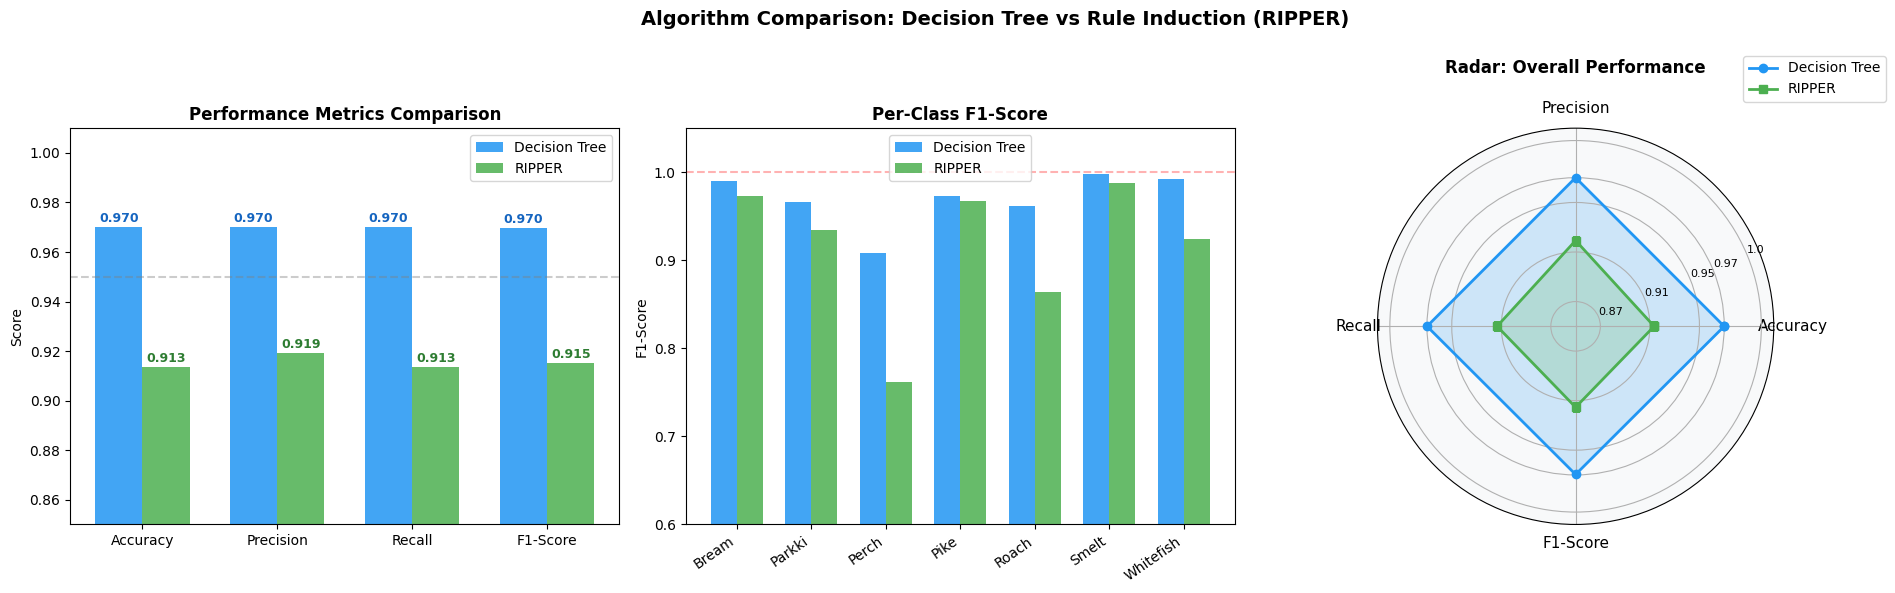

In [ ]:
# ── Comparative Visualisation ─────────────────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
dt_vals = [acc_dt, prec_dt, rec_dt, f1_dt]
ri_vals = [acc_ri, prec_ri, rec_ri, f1_ri]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Algorithm Comparison: Decision Tree vs Rule Induction (RIPPER)',
             fontsize=14, fontweight='bold')

# Bar chart
x = np.arange(len(metrics))
w = 0.35
axes[0].bar(x - w/2, dt_vals, w, label='Decision Tree', color='#2196F3', alpha=0.85)
axes[0].bar(x + w/2, ri_vals, w, label='RIPPER', color='#4CAF50', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0.85, 1.01)
axes[0].set_ylabel('Score')
axes[0].set_title('Performance Metrics Comparison', fontweight='bold')
axes[0].legend()
axes[0].axhline(0.95, color='gray', linestyle='--', alpha=0.4, label='0.95 baseline')
for i, (dv, rv) in enumerate(zip(dt_vals, ri_vals)):
    axes[0].text(i - w/2, dv + 0.002, f'{dv:.3f}', ha='center', fontsize=9, fontweight='bold', color='#1565C0')
    axes[0].text(i + w/2, rv + 0.002, f'{rv:.3f}', ha='center', fontsize=9, fontweight='bold', color='#2E7D32')

# Per-class F1 comparison
rep_dt = classification_report(y_test, y_pred_dt, target_names=le.classes_, output_dict=True)
rep_ri = classification_report(y_test_str, y_pred_ri, output_dict=True, zero_division=0)

class_f1_dt = [rep_dt[c]['f1-score'] for c in le.classes_]
class_f1_ri = [rep_ri.get(c, {}).get('f1-score', 0) for c in species_list]

x2 = np.arange(len(species_list))
axes[1].bar(x2 - w/2, class_f1_dt, w, label='Decision Tree', color='#2196F3', alpha=0.85)
axes[1].bar(x2 + w/2, class_f1_ri, w, label='RIPPER', color='#4CAF50', alpha=0.85)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(species_list, rotation=35, ha='right')
axes[1].set_ylim(0.6, 1.05)
axes[1].set_ylabel('F1-Score')
axes[1].set_title('Per-Class F1-Score', fontweight='bold')
axes[1].legend()
axes[1].axhline(1.0, color='red', linestyle='--', alpha=0.3)

# Radar chart
categories = metrics
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
ax3 = fig.add_subplot(133, polar=True)
ax3.set_facecolor('#f8f9fa')
dt_plot = dt_vals + dt_vals[:1]
ri_plot = ri_vals + ri_vals[:1]
ax3.plot(angles, dt_plot, 'o-', linewidth=2, color='#2196F3', label='Decision Tree')
ax3.fill(angles, dt_plot, alpha=0.2, color='#2196F3')
ax3.plot(angles, ri_plot, 's-', linewidth=2, color='#4CAF50', label='RIPPER')
ax3.fill(angles, ri_plot, alpha=0.2, color='#4CAF50')
ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(categories, fontsize=11)
ax3.set_ylim(0.85, 1.01)
ax3.set_yticks([0.87, 0.91, 0.95, 0.97, 1.0])
ax3.set_yticklabels(['0.87','0.91','0.95','0.97','1.0'], fontsize=8)
ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.2))
ax3.set_title('Radar: Overall Performance', fontweight='bold', pad=20)
axes[2].remove()  # remove placeholder

plt.tight_layout()
plt.savefig('comparison.png', dpi=120, bbox_inches='tight')
plt.show()

### Naïve Bayes vs Neural Network

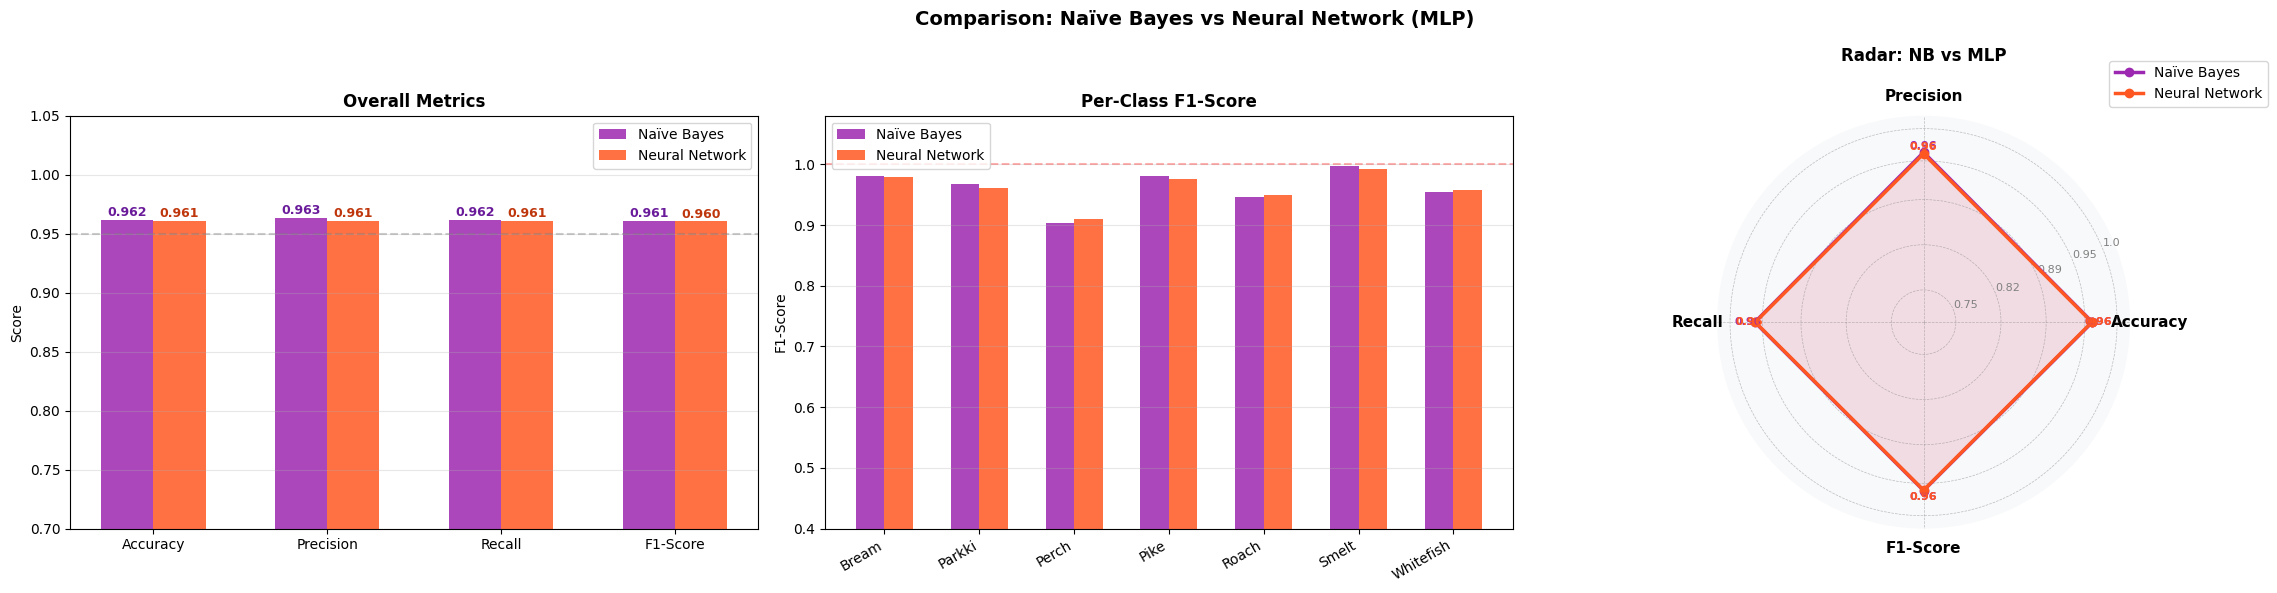

In [78]:


nb_vals  = [acc_nb,  prec_nb,  rec_nb,  f1_nb]
mlp_vals = [acc_mlp, prec_mlp, rec_mlp, f1_mlp]
bar_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

fig, axes = plt.subplots(1, 3, figsize=(24, 6))
fig.suptitle('Comparison: Naïve Bayes vs Neural Network (MLP)',
             fontsize=14, fontweight='bold')

x = np.arange(len(bar_metrics))
w = 0.30
bars_nb  = axes[0].bar(x - w/2, nb_vals,  w, label='Naïve Bayes',   color='#9C27B0', alpha=0.85)
bars_mlp = axes[0].bar(x + w/2, mlp_vals, w, label='Neural Network', color='#FF5722', alpha=0.85)
for bar, v in zip(bars_nb,  nb_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                 f'{v:.3f}', ha='center', fontsize=9, fontweight='bold', color='#6A1B9A')
for bar, v in zip(bars_mlp, mlp_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                 f'{v:.3f}', ha='center', fontsize=9, fontweight='bold', color='#BF360C')
axes[0].set_xticks(x)
axes[0].set_xticklabels(bar_metrics)
axes[0].set_ylim(0.70, 1.05)
axes[0].set_ylabel('Score')
axes[0].set_title('Overall Metrics', fontweight='bold')
axes[0].legend()
axes[0].axhline(0.95, color='gray', linestyle='--', alpha=0.4)
axes[0].grid(axis='y', alpha=0.3)

# Per-class F1 — NB vs MLP
rep_nb  = classification_report(y_test, y_pred_nb,  target_names=le.classes_, output_dict=True)
rep_mlp = classification_report(y_test, y_pred_mlp, target_names=le.classes_, output_dict=True)
class_f1_nb  = [rep_nb[c]['f1-score']  for c in le.classes_]
class_f1_mlp = [rep_mlp[c]['f1-score'] for c in le.classes_]

x2 = np.arange(len(le.classes_))
axes[1].bar(x2 - w/2, class_f1_nb,  w, label='Naïve Bayes',   color='#9C27B0', alpha=0.85)
axes[1].bar(x2 + w/2, class_f1_mlp, w, label='Neural Network', color='#FF5722', alpha=0.85)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(le.classes_, rotation=30, ha='right')
axes[1].set_ylim(0.40, 1.08)
axes[1].set_ylabel('F1-Score')
axes[1].set_title('Per-Class F1-Score', fontweight='bold')
axes[1].legend()
axes[1].axhline(1.0, color='red', linestyle='--', alpha=0.3)
axes[1].grid(axis='y', alpha=0.3)

# Radar chart — NB vs MLP
N      = len(bar_metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

ax_r = fig.add_subplot(133, polar=True)
ax_r.set_facecolor('#f8f9fa')

for algo, vals, color in zip(['Naïve Bayes', 'Neural Network'],
                              [nb_vals, mlp_vals],
                              ['#9C27B0', '#FF5722']):
    v = vals + vals[:1]
    ax_r.plot(angles, v, 'o-', linewidth=2.5, color=color, label=algo)
    ax_r.fill(angles, v, alpha=0.08, color=color)
    for angle, val in zip(angles[:-1], vals):
        ax_r.text(angle, val + 0.01, f'{val:.2f}',
                  ha='center', va='center', fontsize=8,
                  color=color, fontweight='bold')

ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(bar_metrics, fontsize=11, fontweight='bold')
ax_r.set_ylim(0.70, 1.02)
ax_r.set_yticks([0.75, 0.82, 0.89, 0.95, 1.0])
ax_r.set_yticklabels(['0.75','0.82','0.89','0.95','1.0'], fontsize=8, color='gray')
ax_r.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax_r.spines['polar'].set_visible(False)
ax_r.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax_r.set_title('Radar: NB vs MLP', fontweight='bold', pad=20)
axes[2].remove()

plt.tight_layout()
plt.savefig('nb_vs_mlp_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# Summary table NB vs MLP
comp_2 = pd.DataFrame({
    'Metric': bar_metrics + ['CV Accuracy'],
    'Naïve Bayes':    [f'{v:.4f}' for v in nb_vals]  + [f'{cv_nb:.4f}'],
    'Neural Network': [f'{v:.4f}' for v in mlp_vals] + [f'{cv_mlp:.4f}'],
})
comp_2['Winner'] = [
    'NB' if a > b else 'MLP'
    for a, b in zip(
        [acc_nb, prec_nb, rec_nb, f1_nb, cv_nb],
        [acc_mlp, prec_mlp, rec_mlp, f1_mlp, cv_mlp]
    )
]
comp_2.set_index('Metric', inplace=True)
print('\n===== NB vs MLP Summary =====')
print(comp_2.to_string())
display(comp_2)


===== NB vs MLP Summary =====
            Naïve Bayes Neural Network Winner
Metric                                       
Accuracy         0.9616         0.9609     NB
Precision        0.9633         0.9611     NB
Recall           0.9616         0.9609     NB
F1-Score         0.9611         0.9605     NB
CV Accuracy      0.9645         0.9628     NB


,Naïve Bayes,Neural Network,Winner
Metric,,,
Accuracy,0.9616,0.9609,NB
Precision,0.9633,0.9611,NB
Recall,0.9616,0.9609,NB
F1-Score,0.9611,0.9605,NB
CV Accuracy,0.9645,0.9628,NB


### Comparison between the four algorithms

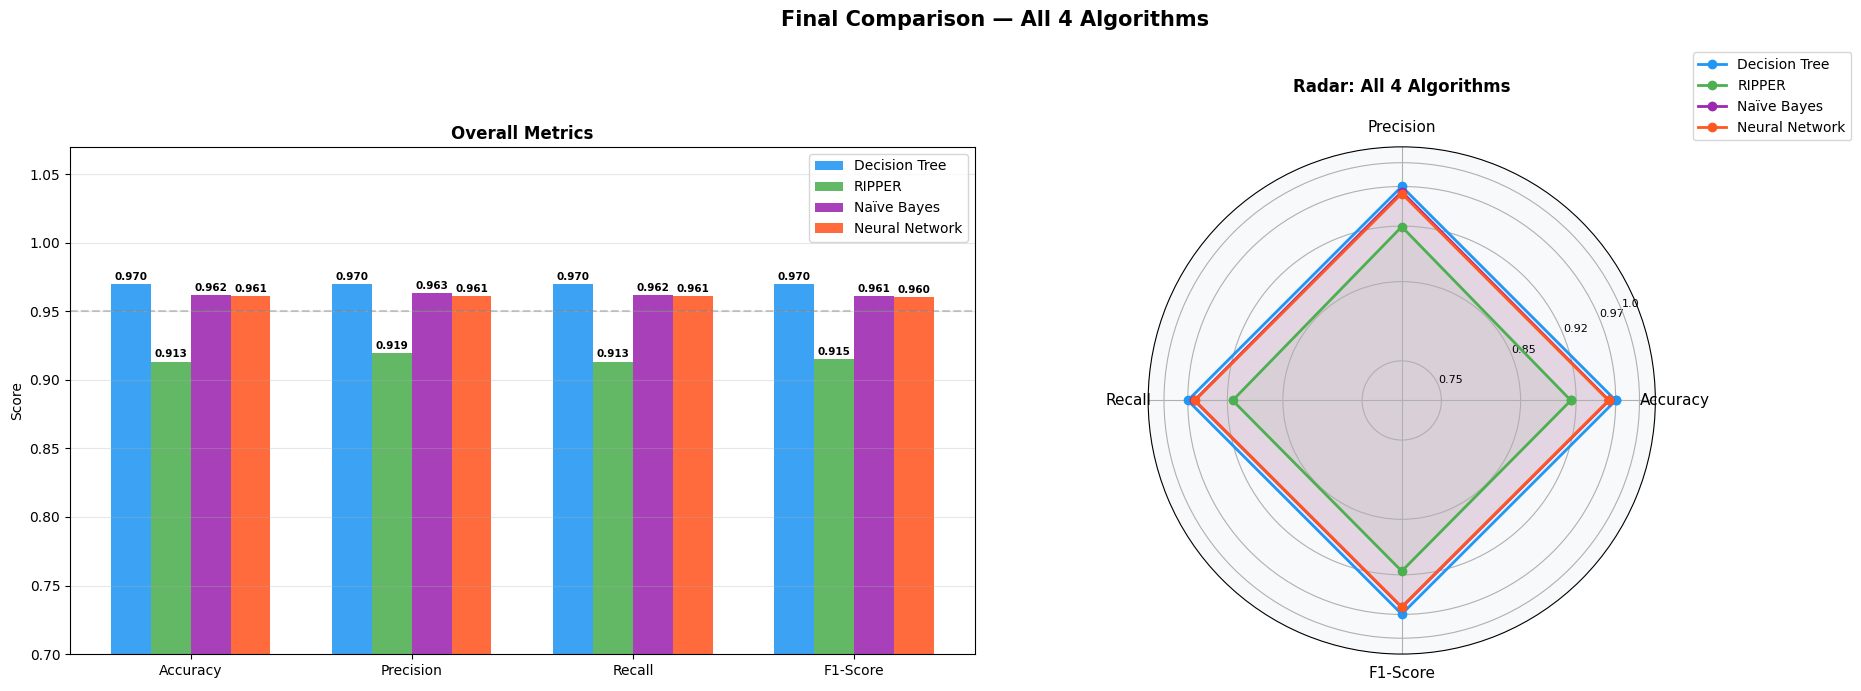

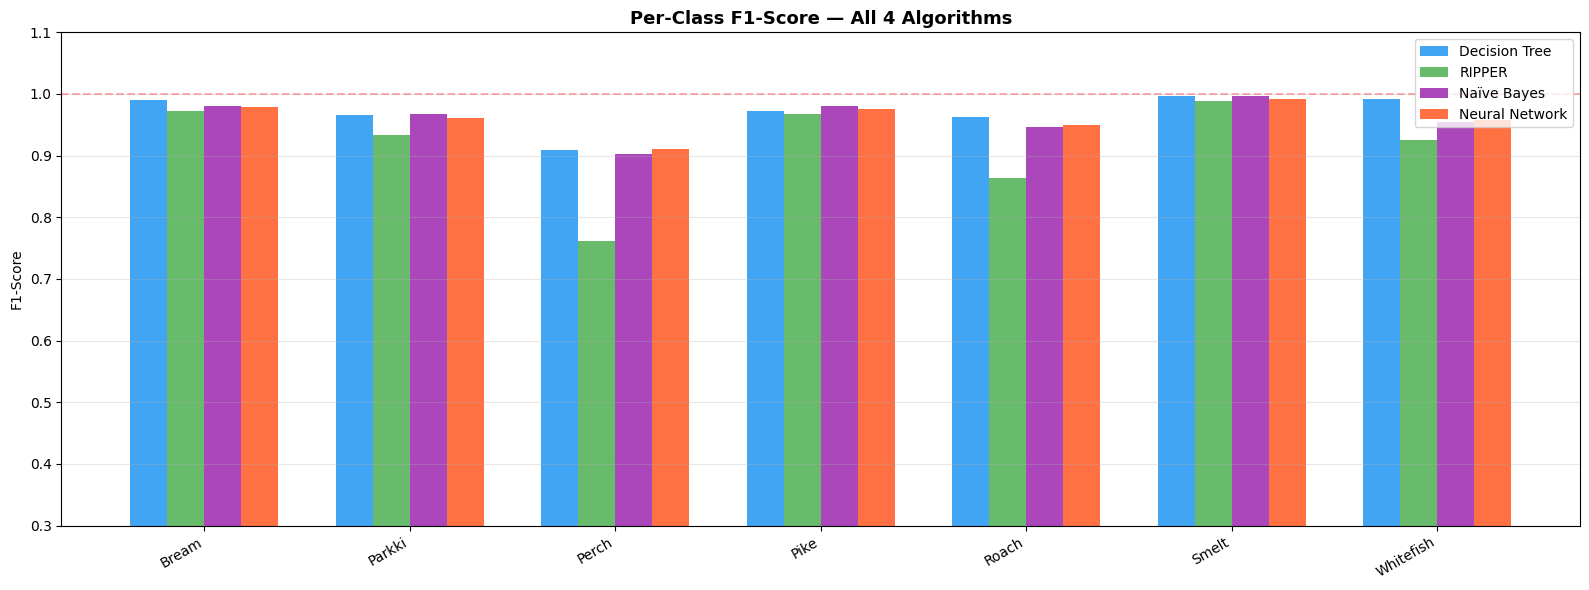


========== FINAL 4-ALGORITHM SUMMARY ==========
             Decision Tree  RIPPER  Naïve Bayes  Neural Network
Accuracy             97.00   91.34        96.16           96.09
Precision            97.00   91.93        96.33           96.11
Recall               97.00   91.34        96.16           96.09
F1-Score             96.96   91.54        96.11           96.05
CV Accuracy          96.63     NaN        96.45           96.28 (%)
None


,Decision Tree,RIPPER,Naïve Bayes,Neural Network
Accuracy,97.00%,91.34%,96.16%,96.09%
Precision,97.00%,91.93%,96.33%,96.11%
Recall,97.00%,91.34%,96.16%,96.09%
F1-Score,96.96%,91.54%,96.11%,96.05%
CV Accuracy,96.63%,nan%,96.45%,96.28%


None

In [83]:
algo_names  = ['Decision Tree', 'RIPPER', 'Naïve Bayes', 'Neural Network']
algo_colors = ['#2196F3',       '#4CAF50', '#9C27B0',     '#FF5722']
all_vals = [
    [acc_dt,  prec_dt,  rec_dt,  f1_dt],
    [acc_ri,  prec_ri,  rec_ri,  f1_ri],
    [acc_nb,  prec_nb,  rec_nb,  f1_nb],
    [acc_mlp, prec_mlp, rec_mlp, f1_mlp],
]

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Final Comparison — All 4 Algorithms',
             fontsize=15, fontweight='bold')

x  = np.arange(len(bar_metrics))
w4 = 0.18
for i, (algo, vals, color) in enumerate(zip(algo_names, all_vals, algo_colors)):
    offset = (i - 1.5) * w4
    bars = axes[0].bar(x + offset, vals, w4, label=algo, color=color, alpha=0.88)
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                     f'{v:.3f}', ha='center', fontsize=7.5, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(bar_metrics)
axes[0].set_ylim(0.70, 1.07)
axes[0].set_ylabel('Score')
axes[0].set_title('Overall Metrics', fontweight='bold')
axes[0].legend()
axes[0].axhline(0.95, color='gray', linestyle='--', alpha=0.4)
axes[0].grid(axis='y', alpha=0.3)

# Radar chart 
N      = len(bar_metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

ax_radar = fig.add_subplot(122, polar=True)
ax_radar.set_facecolor('#f8f9fa')
for algo, vals, color in zip(algo_names, all_vals, algo_colors):
    v = vals + vals[:1]
    ax_radar.plot(angles, v, 'o-', linewidth=2, color=color, label=algo)
    ax_radar.fill(angles, v, alpha=0.08, color=color)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(bar_metrics, fontsize=11)
ax_radar.set_ylim(0.70, 1.02)
ax_radar.set_yticks([0.75, 0.85, 0.92, 0.97, 1.0])
ax_radar.set_yticklabels(['0.75','0.85','0.92','0.97','1.0'], fontsize=8)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.4, 1.2))
ax_radar.set_title('Radar: All 4 Algorithms', fontweight='bold', pad=20)
axes[1].remove()

plt.tight_layout()
plt.savefig('4_algo_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

# Per-class F1 
rep_dt_d  = classification_report(y_test, y_pred_dt,  target_names=le.classes_, output_dict=True)
rep_ri_d  = classification_report(y_test_str, y_pred_ri, output_dict=True, zero_division=0)
class_f1_all = [
    [rep_dt_d[c]['f1-score']            for c in le.classes_],
    [rep_ri_d.get(c,{}).get('f1-score', 0) for c in le.classes_],
    [rep_nb[c]['f1-score']              for c in le.classes_],
    [rep_mlp[c]['f1-score']             for c in le.classes_],
]

x3 = np.arange(len(le.classes_))
fig, ax = plt.subplots(figsize=(16, 6))
for i, (algo, vals, color) in enumerate(zip(algo_names, class_f1_all, algo_colors)):
    offset = (i - 1.5) * w4
    ax.bar(x3 + offset, vals, w4, label=algo, color=color, alpha=0.85)
ax.set_xticks(x3)
ax.set_xticklabels(le.classes_, rotation=30, ha='right')
ax.set_ylim(0.30, 1.10)
ax.set_ylabel('F1-Score')
ax.set_title('Per-Class F1-Score — All 4 Algorithms', fontweight='bold', fontsize=13)
ax.legend()
ax.axhline(1.0, color='red', linestyle='--', alpha=0.3)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_f1_4algos.png', dpi=120, bbox_inches='tight')
plt.show()

# Final summary table 
cv_vals = [cv_dt, float('nan'), cv_nb, cv_mlp]
final_df = pd.DataFrame(
    {a: v + [cv] for a, v, cv in zip(algo_names, all_vals, cv_vals)},
    index=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'CV Accuracy']
)
print('\n========== FINAL 4-ALGORITHM SUMMARY ==========')
print(print((final_df * 100).round(2).to_string() + " (%)"))
print('================================================')
display(display((final_df * 100).round(2).style.highlight_max(axis=1, color='#c8e6c9').format("{:.2f}%")))

# Chapter 7: Results and Comparison

### 7.1 Performance Summary

| Criterion | Decision Tree | RIPPER | Naïve Bayes | Neural Network |
|---|---|---|---|---|
| **Accuracy** | **97.00%** | 91.34% | 96.16% | 96.09% |
| **F1-Score** | **96.96%** | 91.54% | 96.11% | 96.05% |
| **Precision** | **97.00%** | 91.93% | 96.33% | 96.11% |
| **Recall** | **97.00%** | 91.34% | 96.16% | 96.09% |
| **CV Accuracy** | **96.63%** | — | 96.45% | 96.28% |
| Interpretability | Medium (tree structure) | High (IF-THEN rules) | Medium (class means) | Low (black box) |
| Model Complexity | 56 leaves, depth 10 | 305 rules total | 7 Gaussian distributions | 2 hidden layers (128, 64) |
| Training Speed | Fast | Slower (OvR × 7) | Very fast | Moderate |

### 7.2 Key Findings

**Decision Tree** achieved the highest accuracy (97.00%) through hierarchical partitioning of the continuous feature space. The most informative splits were on `Weight`, `Length2`, and `Height`, confirmed by feature importance scores. The model generalised reliably with a cross-validated accuracy of 96.63%.

**Rule Induction (RIPPER)** reached 91.34% accuracy, the lowest among all four algorithms. It struggled most with `Perch` (F1 = 0.76) due to its overlapping morphology with `Roach`, `Parkki`, and `Whitefish`, requiring 91 rules — the largest ruleset of any class. By contrast, `Smelt` was isolated with just 6 rules, reflecting its distinctively small weight and dimensions.

**Naïve Bayes** achieved 96.16% accuracy despite its strong independence assumption. It performed well because the inter-class differences in feature means are large enough to provide sufficient discriminative signal. Smelt was again perfectly classified, while Perch remained the weakest class, consistent with all other models.

**Neural Network (MLP)** achieved 96.09% accuracy, virtually identical to Naïve Bayes across every metric. Despite its architectural complexity, the model brought no measurable gain over the simpler probabilistic approach. The training loss converged quickly within the first few iterations, and early stopping halted training automatically at iteration 62.

### 7.3 When to Use Each Algorithm

- **Use Decision Trees** when predictive accuracy is the priority and the dataset has many continuous features with non-linear relationships.
- **Use Rule Induction** when stakeholders need transparent, auditable IF-THEN logic — for example, in regulatory or research contexts requiring explicit and documented decision criteria.
- **Use Naïve Bayes** when speed and simplicity are important and a lightweight interpretable baseline is needed, as it matched the Neural Network at a fraction of the training cost.
- **Use Neural Networks** when the dataset is larger or more complex and non-linear patterns are expected to be more intricate than what a single decision tree can capture.

### 7.4 Conclusion

On the Fish Species dataset, the **Decision Tree outperforms all three other algorithms** across every evaluation metric. Naïve Bayes and the Neural Network performed nearly identically and ranked second, while RIPPER trailed by approximately six percentage points. All four algorithms consistently agreed that `Smelt` is the easiest species to classify and `Perch` is the hardest, confirming that classification difficulty is driven by the data distribution rather than any individual algorithm's limitation. Both the Decision Tree and RIPPER confirm that fish species can be reliably classified from physical measurements alone, with the Decision Tree finding more discriminative boundaries in the overlapping feature space of species like Perch and Roach.